# Analyse des Données et Visualisation
## Dataset : Loisirs

## 1. Installation des bibliothèques

In [1]:
!pip install pandas matplotlib seaborn prince scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.3/197.3 kB 1.6 MB/s eta 0:00:00


## 2. Importation des bibliothèques

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import prince

plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['font.size'] = 11


## 3. Chargement du dataset

In [4]:
loisirs = pd.read_csv('AnaDo_JeuDonnees_Loisirs.csv', sep=';')
loisirs.head()


,Lecture,Ecouter musique,Cinema,Spectacle,Exposition,Ordinateur,Sport,Marche,Voyage,Jouer musique,...,Jardinage,Tricot,Cuisine,Peche,TV,Sexe,Age,Situation matrimoniale,Profession,Nb activites
0,O,O,O,O,O,N,O,O,O,N,...,N,N,N,N,2,F,"(55,65]",Marie,cadre,11
1,O,N,N,N,O,N,O,O,N,N,...,O,N,N,N,4,M,"(45,55]",Marie,NaN,9
2,O,O,N,N,O,N,N,N,O,N,...,N,N,N,N,4,F,"(25,35]",reMarie,cadre,5
3,O,N,N,N,O,N,O,N,O,N,...,N,N,N,N,1,M,"(75,85]",Marie,NaN,5
4,O,O,O,O,N,N,N,O,N,N,...,N,N,N,N,3,M,"(55,65]",Marie,employe,6


## 4. Informations générales

In [5]:
print("Dimensions :", loisirs.shape)
print(loisirs.dtypes)


Dimensions : (8403, 23)
Lecture                   object
Ecouter musique           object
Cinema                    object
Spectacle                 object
Exposition                object
Ordinateur                object
Sport                     object
Marche                    object
Voyage                    object
Jouer musique             object
Collection                object
Activite benevole         object
Bricolage                 object
Jardinage                 object
Tricot                    object
Cuisine                   object
Peche                     object
TV                         int64
Sexe                      object
Age                       object
Situation matrimoniale    object
Profession                object
Nb activites               int64
dtype: object


## 5. Résumé statistique

In [6]:
loisirs.describe(include='all')

,Lecture,Ecouter musique,Cinema,Spectacle,Exposition,Ordinateur,Sport,Marche,Voyage,Jouer musique,...,Jardinage,Tricot,Cuisine,Peche,TV,Sexe,Age,Situation matrimoniale,Profession,Nb activites
count,8403,8403,8403,8403,8403,8403,8403,8403,8403,8403,...,8403,8403,8403,8403,8403.000000,8403,8403,8403,6905,8403.000000
unique,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,NaN,2,8,5,7,NaN
top,O,O,N,N,N,N,N,N,N,N,...,N,N,N,N,NaN,F,"(45,55]",Marie,employe,NaN
freq,5646,5947,5044,5978,5808,5245,5308,4228,5040,6943,...,5047,6990,4717,7458,NaN,4616,1837,4333,2552,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.354873,NaN,NaN,NaN,NaN,6.866000
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.333283,NaN,NaN,NaN,NaN,3.382593
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,7.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,9.000000


## 6. Valeurs manquantes

In [7]:
print(loisirs.isnull().sum())

Lecture                      0
Ecouter musique              0
Cinema                       0
Spectacle                    0
Exposition                   0
Ordinateur                   0
Sport                        0
Marche                       0
Voyage                       0
Jouer musique                0
Collection                   0
Activite benevole            0
Bricolage                    0
Jardinage                    0
Tricot                       0
Cuisine                      0
Peche                        0
TV                           0
Sexe                         0
Age                          0
Situation matrimoniale       0
Profession                1498
Nb activites                 0
dtype: int64


## 7. Transformation des variables catégorielles

In [8]:
loisirs['TV'] = loisirs['TV'].astype('category')

## 8. Liste des activités

In [9]:
activites = loisirs.columns[:18]
print(activites)


Index(['Lecture', 'Ecouter musique', 'Cinema', 'Spectacle', 'Exposition',
       'Ordinateur', 'Sport', 'Marche', 'Voyage', 'Jouer musique',
       'Collection', 'Activite benevole', 'Bricolage', 'Jardinage', 'Tricot',
       'Cuisine', 'Peche', 'TV'],
      dtype='object')


## 9. Nombre de personnes pratiquant chaque activité

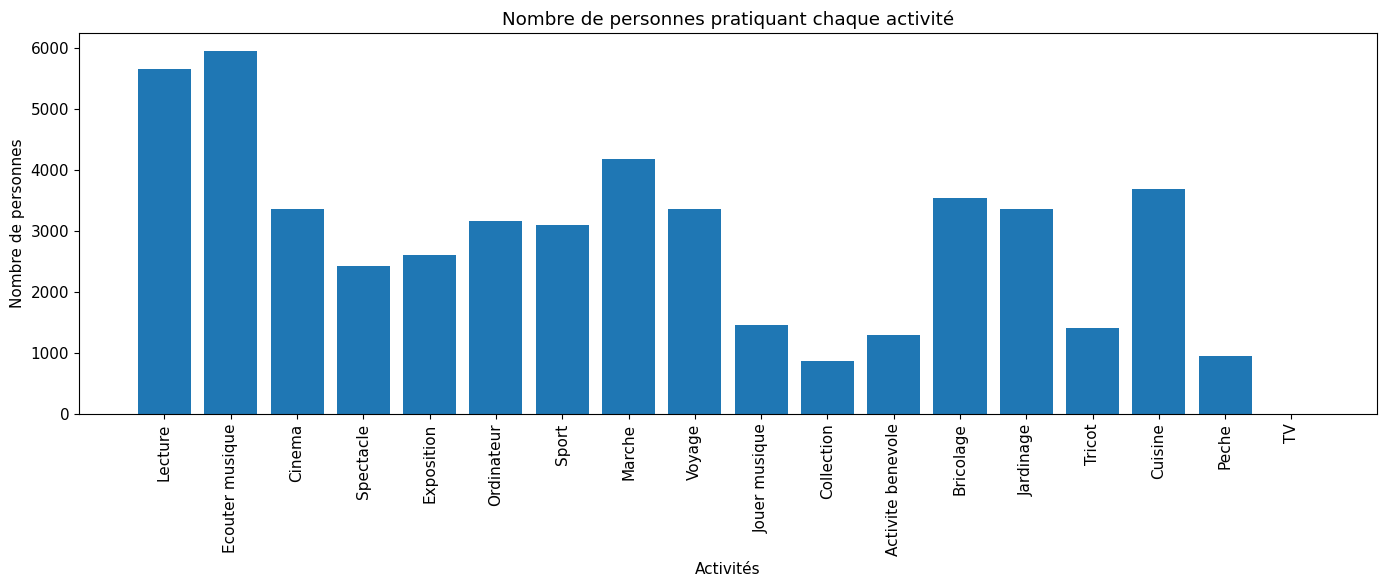

In [10]:
counts = [(loisirs[col] == 'O').sum() for col in activites]

plt.figure(figsize=(14,6))
plt.bar(activites, counts)
plt.xticks(rotation=90)
plt.title("Nombre de personnes pratiquant chaque activité")
plt.xlabel("Activités")
plt.ylabel("Nombre de personnes")
plt.tight_layout()
plt.show()


## 10. Répartition Homme/Femme

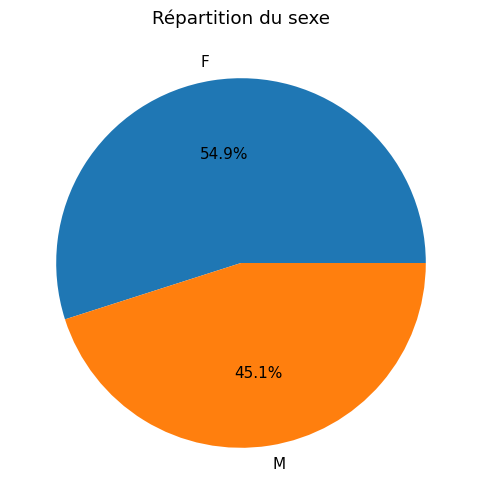

In [11]:
plt.figure(figsize=(6,6))
loisirs['Sexe'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Répartition du sexe")
plt.ylabel('')
plt.show()


## 11. Distribution des âges

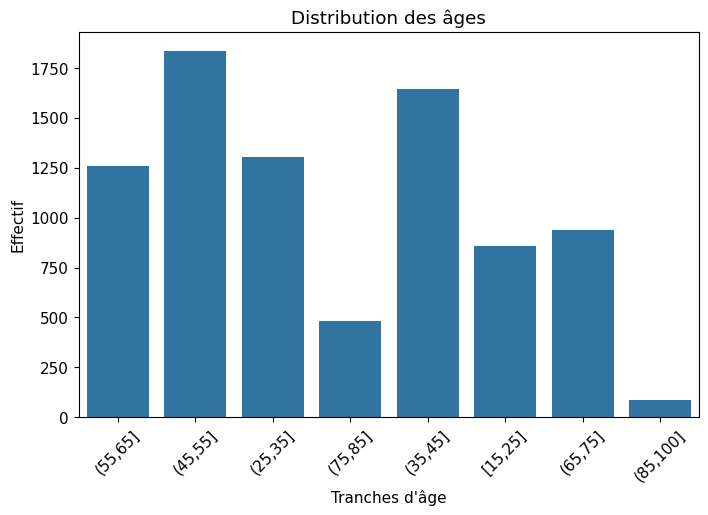

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=loisirs, x='Age')
plt.title("Distribution des âges")
plt.xlabel("Tranches d'âge")
plt.ylabel("Effectif")
plt.xticks(rotation=45)
plt.show()


## 12. Distribution du nombre d’activités

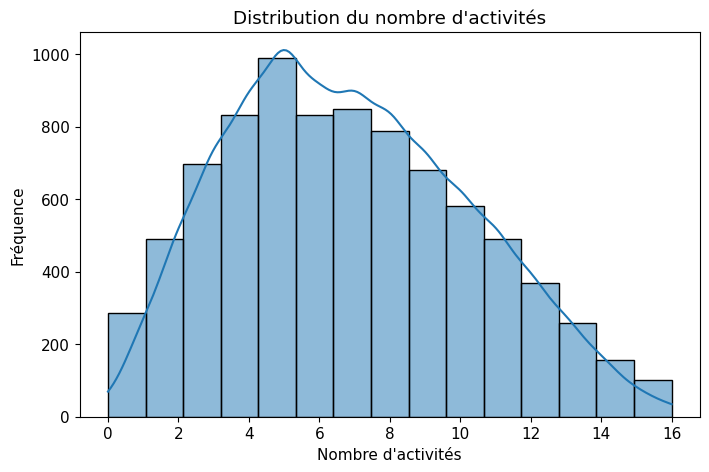

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(loisirs['Nb activites'], bins=15, kde=True)
plt.title("Distribution du nombre d'activités")
plt.xlabel("Nombre d'activités")
plt.ylabel("Fréquence")
plt.show()


## 13. Répartition des professions

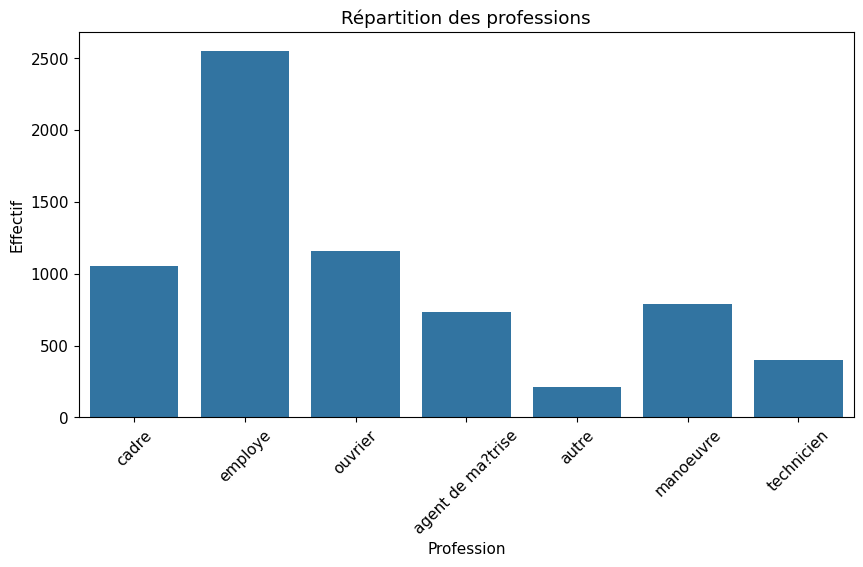

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(data=loisirs, x='Profession')
plt.title("Répartition des professions")
plt.xlabel("Profession")
plt.ylabel("Effectif")
plt.xticks(rotation=45)
plt.show()


## 14. Tableau croisé Sport / Sexe

In [15]:
sport_sexe = pd.crosstab(loisirs['Sexe'], loisirs['Sport'])
print(sport_sexe)


Sport     N     O
Sexe             
F      3074  1542
M      2234  1553


## 15. Graphique Sport selon le sexe

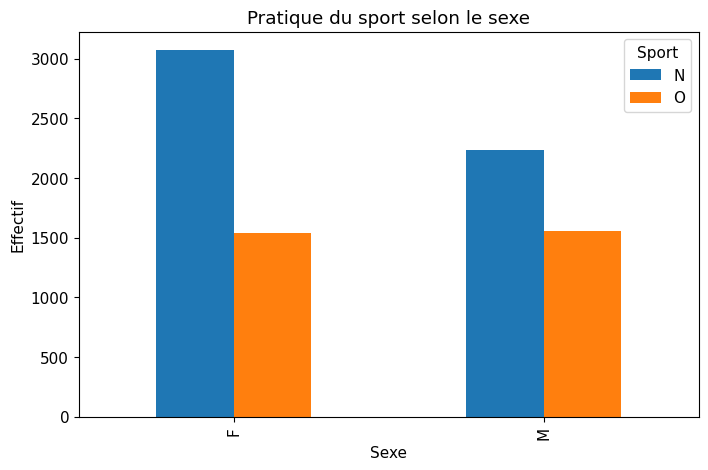

In [16]:
sport_sexe.plot(kind='bar')
plt.title("Pratique du sport selon le sexe")
plt.xlabel("Sexe")
plt.ylabel("Effectif")
plt.show()


## 16. Encodage des variables

In [17]:
encoded = loisirs.copy()

for col in activites:
    encoded[col] = encoded[col].map({'O':1, 'N':0})


## 17. Heatmap des corrélations

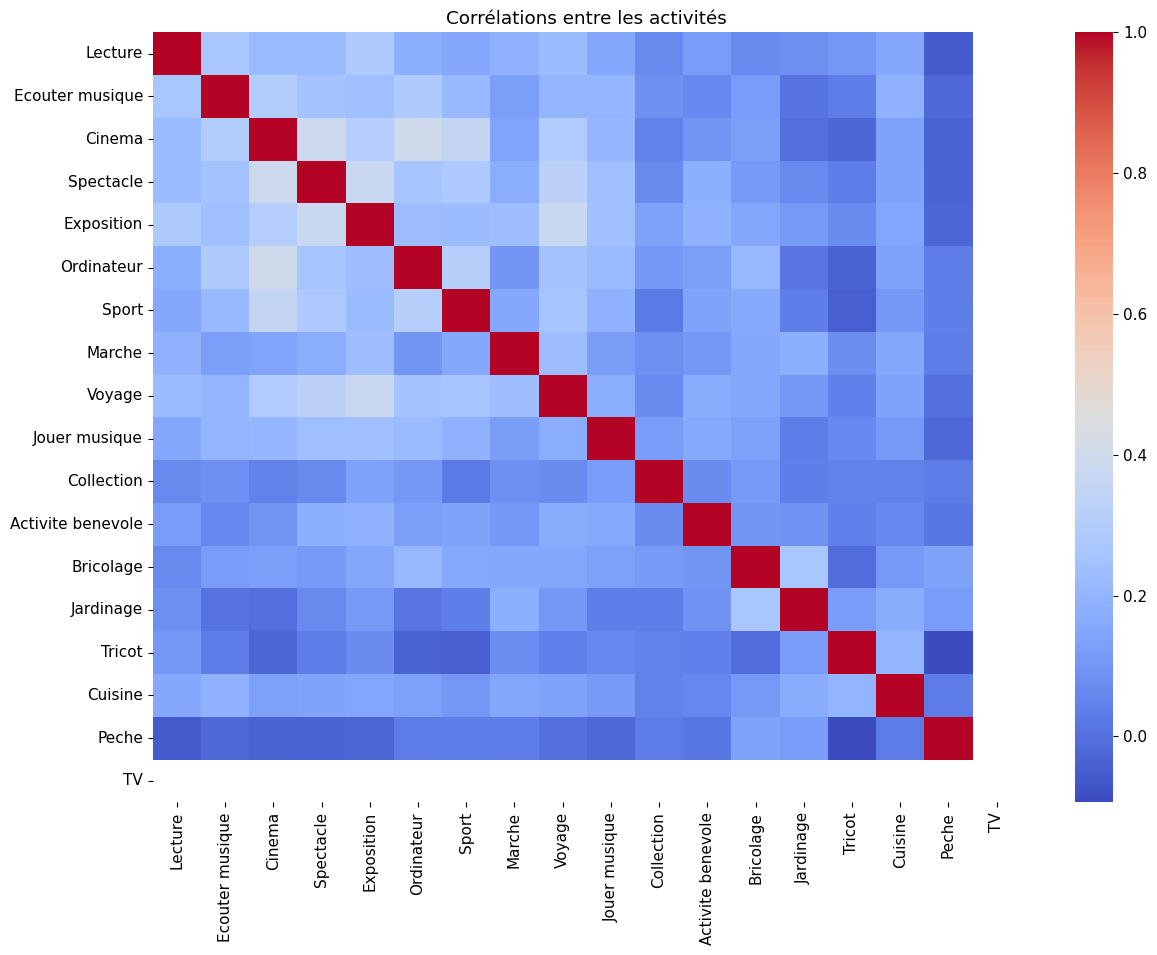

In [18]:
corr = encoded[activites].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Corrélations entre les activités")
plt.show()


## 18. Préparation des données pour l’ACM

In [19]:
loisirs_clean = loisirs.dropna()
mca_data = loisirs_clean.drop(columns=['Nb activites'])


## 19. Analyse des Correspondances Multiples (ACM)

In [20]:
mca = prince.MCA(
    n_components=2,
    random_state=42
)

mca = mca.fit(mca_data)


## 20. Valeurs propres

In [21]:
eigenvalues = mca.eigenvalues_
print(eigenvalues)


[0.17574649 0.09938428]


## 21. Graphique des valeurs propres

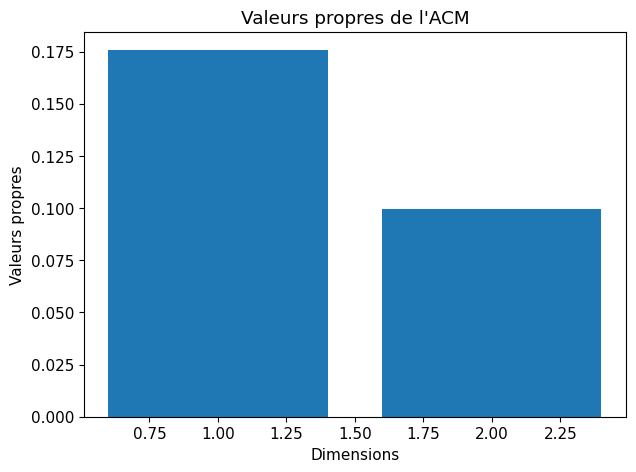

In [22]:
plt.figure(figsize=(7,5))
plt.bar(range(1, len(eigenvalues)+1), eigenvalues)
plt.title("Valeurs propres de l'ACM")
plt.xlabel("Dimensions")
plt.ylabel("Valeurs propres")
plt.show()


## 22. Coordonnées des individus

In [23]:
row_coords = mca.row_coordinates(mca_data)
row_coords.head()


,0,1
0,0.620702,0.119424
2,-0.002462,0.109926
4,-0.052011,0.076979
5,-0.595287,-0.406865
6,-0.138923,-0.355028


## 23. Projection des individus

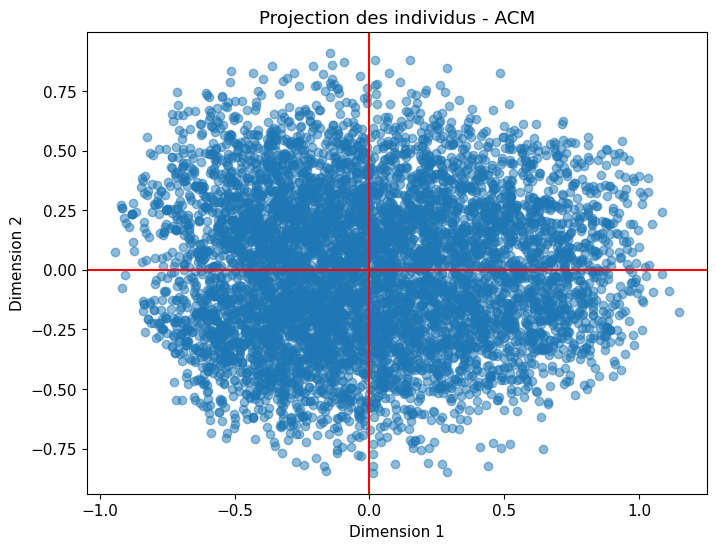

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(row_coords[0], row_coords[1], alpha=0.5)

plt.axhline(0, color='red')
plt.axvline(0, color='red')

plt.title("Projection des individus - ACM")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()


## 24. Coordonnées des variables

In [25]:
col_coords = mca.column_coordinates(mca_data)
col_coords.head()


,0,1
Lecture__N,-0.663774,-0.457059
Lecture__O,0.324019,0.223112
Ecouter musique__N,-0.812757,-0.073453
Ecouter musique__O,0.326984,0.029551
Cinema__N,-0.519581,0.061919


## 25. Projection des variables

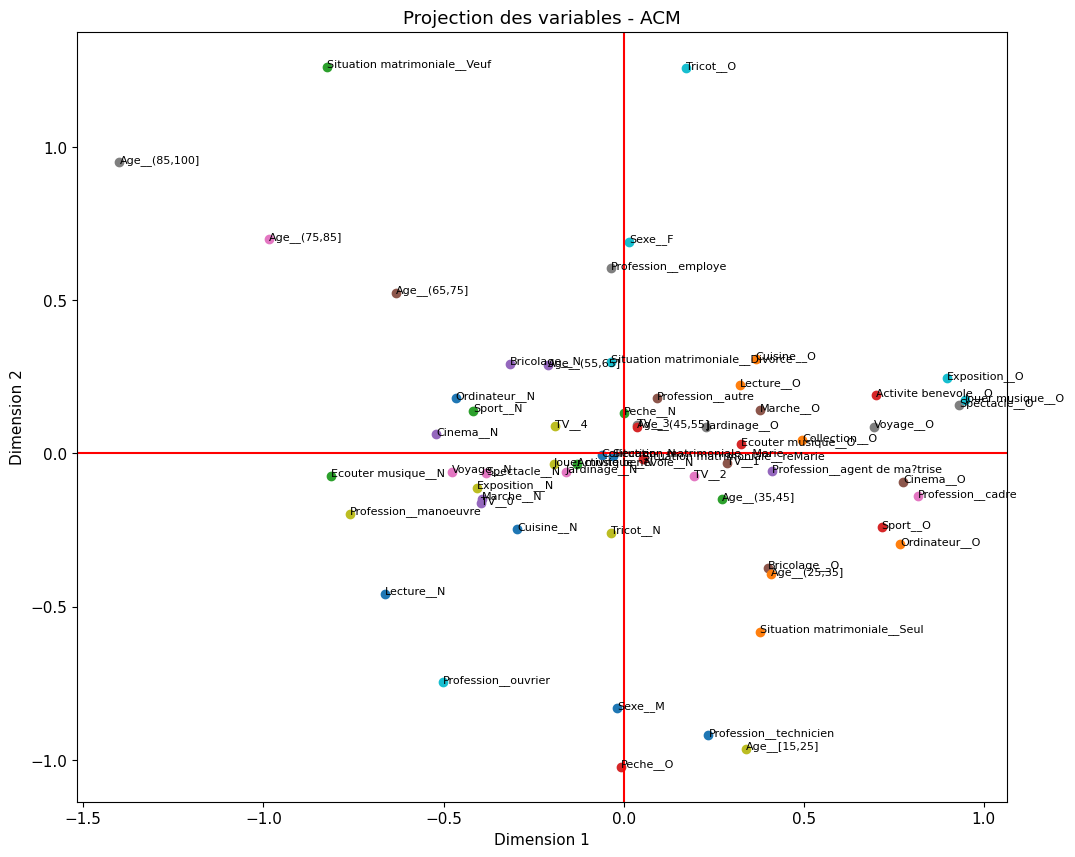

In [26]:
plt.figure(figsize=(12,10))

for i in range(len(col_coords)):
    plt.scatter(col_coords.iloc[i,0], col_coords.iloc[i,1])
    plt.text(
        col_coords.iloc[i,0],
        col_coords.iloc[i,1],
        col_coords.index[i],
        fontsize=8
    )

plt.axhline(0, color='red')
plt.axvline(0, color='red')

plt.title("Projection des variables - ACM")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()


## 26. Projection ACM selon le sexe

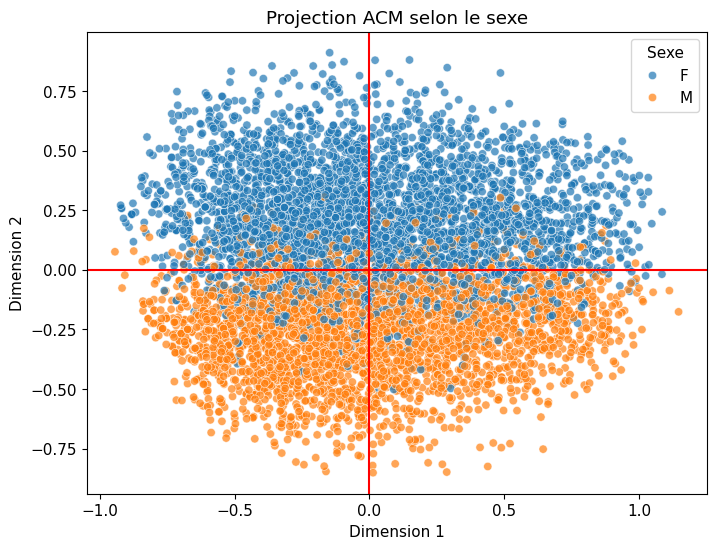

In [27]:
coords = row_coords.copy()
coords['Sexe'] = loisirs_clean['Sexe'].values

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=coords[0],
    y=coords[1],
    hue=coords['Sexe'],
    alpha=0.7
)

plt.axhline(0, color='red')
plt.axvline(0, color='red')

plt.title("Projection ACM selon le sexe")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()


## 27. Conclusion

Cette étude a permis de réaliser une analyse descriptive et une Analyse des Correspondances Multiples (ACM) sur le dataset des loisirs avec Python.

## Rapport d'Analyse et Visualisation des Données de Loisirs

### 1. Introduction

Ce rapport présente une analyse exploratoire et une Analyse des Correspondances Multiples (ACM) sur un dataset concernant les activités de loisirs. L'objectif est de comprendre les habitudes de loisirs de la population étudiée, d'identifier les relations entre les différentes activités, et d'explorer les profils des individus selon leurs caractéristiques socio-démographiques et leurs pratiques.

Le dataset `AnaDo_JeuDonnees_Loisirs.csv` contient des informations sur 8403 individus et 23 variables, incluant 17 activités de loisirs, des données socio-démographiques (âge, sexe, situation matrimoniale, profession) et le nombre total d'activités pratiquées.

### 2. Chargement et Exploration Initiale des Données

Les bibliothèques nécessaires (pandas, matplotlib, seaborn, prince, scikit-learn) ont été installées et importées. Le dataset a été chargé avec succès :

- **Dimensions du dataset**: 8403 observations et 23 variables.
- **Types de données**: La plupart des variables catégorielles (activités, sexe, âge, situation matrimoniale, profession) sont de type `object`, tandis que `TV` et `Nb activites` sont numériques (`int64`). La variable `TV` a été convertie en type `category` pour une meilleure gestion.
- **Résumé statistique**: Les variables catégorielles sont principalement décrites par leur fréquence, montrant par exemple une prédominance de la réponse 'O' (oui) pour la lecture et l'écoute de musique, et 'N' (non) pour des activités comme le tricot ou la pêche.
- **Valeurs manquantes**: Seule la variable 'Profession' présente des valeurs manquantes (1498), qui ont été gérées ultérieurement en les supprimant pour l'Analyse des Correspondances Multiples (ACM).

### 3. Préparation des Données

Pour les analyses, notamment la corrélation et l'ACM :

- **Encodage des activités**: Les variables d'activités (colonnes 0 à 17) ont été encodées numériquement, transformant 'O' (Oui) en 1 et 'N' (Non) en 0. Cela a permis de calculer les corrélations entre les activités.
- **Nettoyage pour l'ACM**: Un nouveau DataFrame, `loisirs_clean`, a été créé en supprimant les lignes contenant des valeurs manquantes dans la colonne 'Profession'. La variable 'Nb activites' a également été retirée pour l'ACM, car elle est une agrégation des variables d'activités et pourrait biaiser l'analyse.

### 4. Analyse Exploratoire des Données (EDA)

L'EDA a révélé plusieurs tendances :

- **Nombre de personnes pratiquant chaque activité**:
  - La lecture et l'écoute de musique sont les activités les plus populaires.
  - Le tricot, la collection, la pêche et jouer de la musique sont les moins pratiquées.
  - `TV` étant un entier entre 0 et 4, ne représente pas une activité binaire comme les autres, ce qui explique son comptage à zéro si 'O' est recherché.

- **Répartition Homme/Femme**: La population est relativement équilibrée, avec légèrement plus de femmes (54.9%) que d'hommes (45.1%).

- **Distribution des âges**: La tranche d'âge la plus représentée est celle des (45,55], suivie des (55,65]. Les individus les plus jeunes (<25] et les plus âgés (>85] sont moins nombreux.

- **Distribution du nombre d'activités**: La distribution est unimodale et légèrement asymétrique, avec un pic autour de 6-7 activités, montrant une diversité dans le nombre d'activités pratiquées par les individus.

- **Répartition des professions**: La catégorie 'employé' est la plus fréquente, suivie par 'cadre'. Il y a une distribution variée des autres professions.

- **Tableau croisé et graphique Sport / Sexe**: Il y a plus de femmes qui ne pratiquent pas de sport que d'hommes, tandis que le nombre d'hommes et de femmes pratiquant un sport est presque égal, suggérant des différences dans la propension à pratiquer le sport selon le genre.

- **Heatmap des corrélations**: La carte thermique des corrélations entre les activités encodées révèle des associations positives entre certaines activités (par exemple, Cinéma, Spectacle, Exposition, Voyage), indiquant que les personnes qui pratiquent l'une sont plus susceptibles de pratiquer les autres. Des corrélations plus faibles ou négatives existent pour d'autres paires d'activités.

### 5. Analyse des Correspondances Multiples (ACM)

L'Analyse des Correspondances Multiples (ACM) a été appliquée aux données nettoyées (`mca_data`) pour explorer les relations entre les catégories de variables catégorielles et les profils d'individus. Deux dimensions ont été retenues.

- **Valeurs propres**:
  - Les valeurs propres des deux premières dimensions sont respectivement de 0.1757 et 0.0994.
  - Ces valeurs indiquent l'importance de chaque dimension dans l'explication de la variance totale. La première dimension explique une part plus significative de l'inertie totale que la seconde.
  - Le graphique des valeurs propres confirme que les premières dimensions capturent la majorité de l'information, et qu'il est pertinent de se concentrer sur les deux premières pour l'interprétation.

- **Projection des individus (row_coords)**:
  - Le nuage de points des individus sur les deux premières dimensions de l'ACM montre une dispersion des points, ce qui suggère une diversité dans les profils de loisirs.
  - Certains groupes d'individus peuvent se former en fonction de leurs similarités dans les pratiques de loisirs.

- **Projection des variables (col_coords)**:
  - Le biplot des variables (catégories des variables originales) est crucial pour interpréter les dimensions.
  - Les catégories de variables proches les unes des autres sur le graphique sont souvent associées. Par exemple, les catégories 'O' (Oui) pour les activités culturelles (Cinéma, Spectacle, Exposition) pourraient se regrouper, tandis que les activités plus solitaires ou domestiques (Tricot, Pêche) pourraient former d'autres groupes.
  - Les catégories éloignées de l'origine contribuent davantage à la formation des axes.
  - Par exemple, 'Lecture__N' et 'Lecture__O' sont positionnés à des extrémités opposées, comme attendu, montrant leur opposition sur la dimension qui les discrimine.
  - Des catégories professionnelles comme 'cadre' et 'employe' et des tranches d'âge ont des positions distinctes, indiquant des profils de loisirs différents associés à ces caractéristiques.

- **Projection ACM selon le sexe (avec `hue` sur le sexe)**:
  - En colorant la projection des individus selon le sexe, on observe si les hommes et les femmes ont des distributions différentes sur les dimensions de l'ACM.
  - Si les nuages de points pour les hommes et les femmes se superposent largement, cela suggère que le sexe n'est pas un facteur discriminant majeur dans les profils de loisirs sur ces dimensions.
  - Cependant, si les nuages sont distincts, cela indiquerait que les hommes et les femmes tendent à avoir des habitudes de loisirs différentes, ce qui peut être analysé plus en détail en regardant les catégories d'activités associées à chaque groupe dans le biplot des variables.

### 6. Conclusion

Cette analyse a permis de brosser un tableau détaillé des habitudes de loisirs et des caractéristiques socio-démographiques associées au sein du dataset `AnaDo_JeuDonnees_Loisirs.csv`.

L'EDA a mis en évidence la popularité de certaines activités comme la lecture et la musique, la répartition équilibrée des genres, et la prédominance des tranches d'âge moyennes. La distribution du nombre d'activités montre que les individus ont tendance à pratiquer un nombre modéré d'activités, avec des corrélations significatives entre des groupes d'activités culturelles.

L'ACM, quant à elle, a permis de réduire la complexité des données catégorielles en deux dimensions principales. Ces dimensions révèlent des oppositions et des proximités entre les catégories de variables, suggérant des typologies de loisirs. Bien que les valeurs propres soient relativement faibles, les projections des individus et des variables offrent des pistes pour la compréhension des profils.

Pour aller plus loin, une interprétation plus approfondie des contributions des catégories aux axes de l'ACM serait nécessaire pour caractériser précisément chaque dimension. Des analyses complémentaires pourraient inclure la classification des individus basée sur les coordonnées de l'ACM pour identifier des segments de population distincts en fonction de leurs loisirs.